# Self-supervised Graph Learning (SGL) for Recommendation

## Objective

In this notebook, we implement **Self-supervised Graph Learning (SGL)** proposed in:

> Self-supervised Graph Learning for Recommendation (SIGIR 2021)

SGL extends LightGCN by introducing **contrastive self-supervised learning**.

Unlike previous recommendation models that rely only on supervised interactions, SGL learns robust user and item representations by maximizing agreement between different augmented views of the interaction graph.

Main Components

- LightGCN Encoder
- Graph Augmentation
- Contrastive Learning
- InfoNCE Loss
- Bayesian Personalized Ranking (BPR)

Notebook Outline

1. Data Loading
2. Data Preprocessing
3. Graph Construction
4. Graph Augmentation
5. LightGCN Encoder
6. Contrastive Learning
7. Joint Optimization
8. Evaluation
9. Model Comparison

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import scipy.sparse as sp

import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split

from sklearn.metrics import (
    accuracy_score,
    roc_auc_score,
    roc_curve
)

import torch
import torch.nn as nn
import torch.nn.functional as F

from torch.utils.data import (
    Dataset,
    DataLoader
)

torch.manual_seed(42)
np.random.seed(42)

In [2]:
rating_columns = [

    "user_id",

    "movie_id",

    "rating",

    "timestamp"

]

ratings = pd.read_csv(

    "../data/u.data",

    sep="\t",

    names=rating_columns

)

ratings["user_id"] -= 1
ratings["movie_id"] -= 1

ratings.head()

,user_id,movie_id,rating,timestamp
0,195,241,3,881250949
1,185,301,3,891717742
2,21,376,1,878887116
3,243,50,2,880606923
4,165,345,1,886397596


In [3]:
user_columns = [

    "user_id",

    "age",

    "gender",

    "occupation",

    "zip_code"

]

users = pd.read_csv(

    "../data/u.user",

    sep="|",

    names=user_columns

)

users["user_id"] -= 1

users.head()

,user_id,age,gender,occupation,zip_code
0,0,24,M,technician,85711
1,1,53,F,other,94043
2,2,23,M,writer,32067
3,3,24,M,technician,43537
4,4,33,F,other,15213


In [4]:
movie_columns = [

    "movie_id",

    "title",

    "release_date",

    "video_release_date",

    "IMDb_URL"

]

genre_columns = [

    "unknown",

    "Action",

    "Adventure",

    "Animation",

    "Children",

    "Comedy",

    "Crime",

    "Documentary",

    "Drama",

    "Fantasy",

    "Film-Noir",

    "Horror",

    "Musical",

    "Mystery",

    "Romance",

    "Sci-Fi",

    "Thriller",

    "War",

    "Western"

]

movie_columns += genre_columns

movies = pd.read_csv(

    "../data/u.item",

    sep="|",

    encoding="latin-1",

    names=movie_columns

)

movies["movie_id"] -= 1

movies.head()

,movie_id,title,release_date,video_release_date,IMDb_URL,unknown,Action,Adventure,Animation,Children,...,Fantasy,Film-Noir,Horror,Musical,Mystery,Romance,Sci-Fi,Thriller,War,Western
0,0,Toy Story (1995),01-Jan-1995,NaN,http://us.imdb.com/M/title-exact?Toy%20Story%2...,0,0,0,1,1,...,0,0,0,0,0,0,0,0,0,0
1,1,GoldenEye (1995),01-Jan-1995,NaN,http://us.imdb.com/M/title-exact?GoldenEye%20(...,0,1,1,0,0,...,0,0,0,0,0,0,0,1,0,0
2,2,Four Rooms (1995),01-Jan-1995,NaN,http://us.imdb.com/M/title-exact?Four%20Rooms%...,0,0,0,0,0,...,0,0,0,0,0,0,0,1,0,0
3,3,Get Shorty (1995),01-Jan-1995,NaN,http://us.imdb.com/M/title-exact?Get%20Shorty%...,0,1,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,4,Copycat (1995),01-Jan-1995,NaN,http://us.imdb.com/M/title-exact?Copycat%20(1995),0,0,0,0,0,...,0,0,0,0,0,0,0,1,0,0


In [5]:
print("Ratings :", ratings.shape)

print("Users   :", users.shape)

print("Movies  :", movies.shape)

Ratings : (100000, 4)
Users   : (943, 5)
Movies  : (1682, 24)


In [6]:
data = ratings.merge(

    users,

    on="user_id"

)

data = data.merge(

    movies,

    on="movie_id"

)

data.head()

,user_id,movie_id,rating,timestamp,age,gender,occupation,zip_code,title,release_date,...,Fantasy,Film-Noir,Horror,Musical,Mystery,Romance,Sci-Fi,Thriller,War,Western
0,195,241,3,881250949,49,M,writer,55105,Kolya (1996),24-Jan-1997,...,0,0,0,0,0,0,0,0,0,0
1,185,301,3,891717742,39,F,executive,00000,L.A. Confidential (1997),01-Jan-1997,...,0,1,0,0,1,0,0,1,0,0
2,21,376,1,878887116,25,M,writer,40206,Heavyweights (1994),01-Jan-1994,...,0,0,0,0,0,0,0,0,0,0
3,243,50,2,880606923,28,M,technician,80525,Legends of the Fall (1994),01-Jan-1994,...,0,0,0,0,0,1,0,0,1,1
4,165,345,1,886397596,47,M,educator,55113,Jackie Brown (1997),01-Jan-1997,...,0,0,0,0,0,0,0,0,0,0


In [7]:
data["label"] = (

    data["rating"] >= 4

).astype(np.float32)

data[

    [

        "rating",

        "label"

    ]

].head()

,rating,label
0,3,0.0
1,3,0.0
2,1,0.0
3,2,0.0
4,1,0.0


In [8]:
print(

    data["label"].value_counts()

)

print()

print(

    data["label"].value_counts(

        normalize=True

    )

)

label
1.0    55375
0.0    44625
Name: count, dtype: int64

label
1.0    0.55375
0.0    0.44625
Name: proportion, dtype: float64


In [9]:
train_df, test_df = train_test_split(

    data,

    test_size=0.2,

    random_state=42,

    stratify=data["label"]

)

print(

    "Train:",

    train_df.shape

)

print(

    "Test :",

    test_df.shape

)

Train: (80000, 32)
Test : (20000, 32)


In [10]:
NUM_USERS = train_df["user_id"].max() + 1

NUM_ITEMS = train_df["movie_id"].max() + 1

print(

    "Users :", NUM_USERS

)

print(

    "Items :", NUM_ITEMS

)

print(

    "Train Ratings :", len(train_df)

)

print(

    "Test Ratings :", len(test_df)

)

Users : 943
Items : 1682
Train Ratings : 80000
Test Ratings : 20000


In [11]:
interaction_matrix = sp.coo_matrix(

    (

        np.ones(

            len(train_df)

        ),

        (

            train_df["user_id"],

            train_df["movie_id"]

        )

    ),

    shape=(

        NUM_USERS,

        NUM_ITEMS

    )

)

interaction_matrix

<COOrdinate sparse matrix of dtype 'float64'
	with 80000 stored elements and shape (943, 1682)>

In [12]:
num_nodes = NUM_USERS + NUM_ITEMS

adjacency_matrix = sp.dok_matrix(

    (

        num_nodes,

        num_nodes

    ),

    dtype=np.float32

)

adjacency_matrix = adjacency_matrix.tolil()

adjacency_matrix[

    :NUM_USERS,

    NUM_USERS:

] = interaction_matrix

adjacency_matrix[

    NUM_USERS:,

    :NUM_USERS

] = interaction_matrix.T

adjacency_matrix = adjacency_matrix.tocsr()

adjacency_matrix

<Compressed Sparse Row sparse matrix of dtype 'float32'
	with 160000 stored elements and shape (2625, 2625)>

In [13]:
degree = np.array(

    adjacency_matrix.sum(axis=1)

).flatten()

degree_inv_sqrt = np.power(

    degree,

    -0.5

)

degree_inv_sqrt[

    np.isinf(

        degree_inv_sqrt

    )

] = 0

D_inv = sp.diags(

    degree_inv_sqrt

)

normalized_graph = (

    D_inv

    @

    adjacency_matrix

    @

    D_inv

)

normalized_graph

<Compressed Sparse Row sparse matrix of dtype 'float32'
	with 160000 stored elements and shape (2625, 2625)>

In [14]:
normalized_graph = normalized_graph.tocoo()

indices = torch.LongTensor(

    np.vstack(

        (

            normalized_graph.row,

            normalized_graph.col

        )

    )

)

values = torch.FloatTensor(

    normalized_graph.data

)

graph = torch.sparse_coo_tensor(

    indices,

    values,

    normalized_graph.shape

)

graph = graph.coalesce()

graph

tensor(indices=tensor([[   0,    0,    0,  ..., 2618, 2620, 2624],
                       [ 943,  944,  945,  ...,  850,  862,  915]]),
       values=tensor([0.0036, 0.0068, 0.0083,  ..., 0.0776, 0.1104, 0.0645]),
       size=(2625, 2625), nnz=160000, layout=torch.sparse_coo)

In [15]:
print(

    graph.shape

)

print(

    graph._nnz()

)

torch.Size([2625, 2625])
160000


In [16]:
def edge_dropout(

    interaction_matrix,

    dropout_rate=0.2

):

    interaction = interaction_matrix.tocoo()

    num_edges = interaction.nnz

    keep_mask = np.random.rand(

        num_edges

    ) > dropout_rate

    dropped_matrix = sp.coo_matrix(

        (

            interaction.data[keep_mask],

            (

                interaction.row[keep_mask],

                interaction.col[keep_mask]

            )

        ),

        shape=interaction.shape

    )

    return dropped_matrix

In [17]:
interaction_view1 = edge_dropout(

    interaction_matrix,

    dropout_rate=0.2

)

interaction_view2 = edge_dropout(

    interaction_matrix,

    dropout_rate=0.2
)

In [18]:
print("Original :", interaction_matrix.nnz)

print("View 1   :", interaction_view1.nnz)

print("View 2   :", interaction_view2.nnz)

Original : 80000
View 1   : 64076
View 2   : 63891


In [19]:
def build_graph(

    interaction_matrix,

    num_users,

    num_items

):

    num_nodes = num_users + num_items

    adjacency = sp.dok_matrix(

        (

            num_nodes,

            num_nodes

        ),

        dtype=np.float32

    )

    adjacency = adjacency.tolil()

    adjacency[

        :num_users,

        num_users:

    ] = interaction_matrix

    adjacency[

        num_users:,

        :num_users

    ] = interaction_matrix.T

    adjacency = adjacency.tocsr()

    degree = np.array(

        adjacency.sum(axis=1)

    ).flatten()

    degree_inv = np.power(

        degree,

        -0.5

    )

    degree_inv[

        np.isinf(

            degree_inv

        )

    ] = 0

    D = sp.diags(

        degree_inv

    )

    normalized = D @ adjacency @ D

    normalized = normalized.tocoo()

    indices = torch.LongTensor(

        np.vstack(

            (

                normalized.row,

                normalized.col

            )

        )

    )

    values = torch.FloatTensor(

        normalized.data

    )

    graph = torch.sparse_coo_tensor(

        indices,

        values,

        normalized.shape

    )

    return graph.coalesce()

In [20]:
graph_view1 = build_graph(

    interaction_view1,

    NUM_USERS,

    NUM_ITEMS

)

graph_view2 = build_graph(

    interaction_view2,

    NUM_USERS,

    NUM_ITEMS
)

In [21]:
print(

    graph_view1.shape

)

print(

    graph_view2.shape
)

torch.Size([2625, 2625])
torch.Size([2625, 2625])


In [22]:
class BPRDataset(Dataset):

    def __init__(

        self,

        dataframe,

        num_items

    ):

        self.users = dataframe["user_id"].values

        self.pos_items = dataframe["movie_id"].values

        self.num_items = num_items

        self.user_history = (

            dataframe

            .groupby(

                "user_id"

            )["movie_id"]

            .apply(set)

            .to_dict()

        )

    def __len__(self):

        return len(

            self.users

        )

    def __getitem__(

        self,

        idx

    ):

        user = self.users[idx]

        pos = self.pos_items[idx]

        while True:

            neg = np.random.randint(

                self.num_items

            )

            if neg not in self.user_history[user]:

                break

        return (

            torch.LongTensor([user]).squeeze(),

            torch.LongTensor([pos]).squeeze(),

            torch.LongTensor([neg]).squeeze()

        )

In [23]:
train_dataset = BPRDataset(

    train_df,

    NUM_ITEMS

)

train_loader = DataLoader(

    train_dataset,

    batch_size=1024,

    shuffle=True
)

In [24]:
batch = next(

    iter(train_loader)

)

for tensor in batch:

    print(

        tensor.shape

    )

torch.Size([1024])
torch.Size([1024])
torch.Size([1024])


In [25]:
class SGLEncoder(nn.Module):

    def __init__(

        self,

        num_users,

        num_items,

        embedding_dim=64,

        num_layers=3

    ):

        super().__init__()

        self.num_users = num_users

        self.num_items = num_items

        self.num_layers = num_layers

        self.user_embedding = nn.Embedding(

            num_users,

            embedding_dim

        )

        self.item_embedding = nn.Embedding(

            num_items,

            embedding_dim

        )

        nn.init.xavier_uniform_(

            self.user_embedding.weight

        )

        nn.init.xavier_uniform_(

            self.item_embedding.weight

        )

    def propagate(

        self,

        graph

    ):

        embeddings = torch.cat(

            [

                self.user_embedding.weight,

                self.item_embedding.weight

            ],

            dim=0

        )

        all_embeddings = [

            embeddings

        ]

        for _ in range(

            self.num_layers

        ):

            embeddings = torch.sparse.mm(

                graph,

                embeddings

            )

            all_embeddings.append(

                embeddings

            )

        final_embedding = torch.stack(

            all_embeddings,

            dim=1

        ).mean(dim=1)

        return final_embedding
    
    def forward(

        self,

        graph_view1,

        graph_view2

    ):

        embedding_view1 = self.propagate(

            graph_view1

        )

        embedding_view2 = self.propagate(

            graph_view2

        )

        return (

            embedding_view1,

            embedding_view2

        )
        
        
    

In [26]:
model = SGLEncoder(

    NUM_USERS,

    NUM_ITEMS,

    embedding_dim=64,

    num_layers=3

)

model

SGLEncoder(
  (user_embedding): Embedding(943, 64)
  (item_embedding): Embedding(1682, 64)
)

In [27]:
embedding1, embedding2 = model(

    graph_view1,

    graph_view2

)

print(

    embedding1.shape

)

print(

    embedding2.shape

)

torch.Size([2625, 64])
torch.Size([2625, 64])


In [28]:
def normalize(

    embedding

):

    return F.normalize(

        embedding,

        dim=1

    )

In [29]:
def similarity(

    x,

    y

):

    return torch.matmul(

        normalize(x),

        normalize(y).T

    )

In [30]:
sim = similarity(

    embedding1,

    embedding2

)

print(

    sim.shape

)

torch.Size([2625, 2625])


In [31]:
def info_nce_loss(

    embedding1,

    embedding2,

    temperature=0.2

):

    embedding1 = normalize(

        embedding1

    )

    embedding2 = normalize(

        embedding2

    )

    similarity_matrix = torch.matmul(

        embedding1,

        embedding2.T

    )

    similarity_matrix /= temperature

    labels = torch.arange(

        similarity_matrix.size(0)

    )

    loss = F.cross_entropy(

        similarity_matrix,

        labels

    )

    return loss

In [32]:
loss = info_nce_loss(

    embedding1,

    embedding2

)

print(loss)

tensor(3.1483, grad_fn=<NllLossBackward0>)


In [33]:
def bpr_loss(

    positive,

    negative

):

    return -torch.mean(

        F.logsigmoid(

            positive

            -

            negative

        )

    )

In [34]:
def sgl_loss(

    positive_scores,

    negative_scores,

    embedding1,

    embedding2,

    lambda_ssl=0.1

):

    ranking = bpr_loss(

        positive_scores,

        negative_scores

    )

    ssl = info_nce_loss(

        embedding1,

        embedding2

    )

    return ranking + lambda_ssl * ssl

In [35]:
optimizer = torch.optim.Adam(

    model.parameters(),

    lr=0.001,

    weight_decay=1e-4

)

In [36]:
def compute_scores(

    embeddings,

    users,

    positive_items,

    negative_items

):

    user_embedding = embeddings[

        users

    ]

    positive_embedding = embeddings[

        NUM_USERS + positive_items

    ]

    negative_embedding = embeddings[

        NUM_USERS + negative_items

    ]

    positive_scores = (

        user_embedding *

        positive_embedding

    ).sum(dim=1)

    negative_scores = (

        user_embedding *

        negative_embedding

    ).sum(dim=1)

    return (

        positive_scores,

        negative_scores

    )

In [37]:
def train_model(

    model,

    train_loader,

    graph_view1,

    graph_view2,

    optimizer,

    epochs=30

):

    history = []

    print(

        "Training SGL..."

    )

    for epoch in range(

        epochs

    ):

        model.train()

        total_loss = 0

        for (

            users,

            positive_items,

            negative_items

        ) in train_loader:

            optimizer.zero_grad()

            (

                embedding1,

                embedding2

            ) = model(

                graph_view1,

                graph_view2

            )

            (

                positive_scores,

                negative_scores

            ) = compute_scores(

                embedding1,

                users,

                positive_items,

                negative_items

            )

            loss = sgl_loss(

                positive_scores,

                negative_scores,

                embedding1,

                embedding2

            )

            loss.backward()

            optimizer.step()

            total_loss += loss.item()

        epoch_loss = total_loss / len(train_loader)

        history.append(

            epoch_loss

        )

        print(

            f"Epoch {epoch+1:2d}/{epochs} | Loss = {epoch_loss:.4f}"

        )

    return history

In [38]:
history = train_model(

    model,

    train_loader,

    graph_view1,

    graph_view2,

    optimizer,

    epochs=20

)

Training SGL...
Epoch  1/20 | Loss = 1.0050
Epoch  2/20 | Loss = 1.0037
Epoch  3/20 | Loss = 1.0034
Epoch  4/20 | Loss = 1.0033
Epoch  5/20 | Loss = 1.0033
Epoch  6/20 | Loss = 1.0032
Epoch  7/20 | Loss = 1.0032
Epoch  8/20 | Loss = 1.0032
Epoch  9/20 | Loss = 1.0031
Epoch 10/20 | Loss = 1.0032
Epoch 11/20 | Loss = 1.0031
Epoch 12/20 | Loss = 1.0033
Epoch 13/20 | Loss = 1.0031
Epoch 14/20 | Loss = 1.0032
Epoch 15/20 | Loss = 1.0031
Epoch 16/20 | Loss = 1.0031
Epoch 17/20 | Loss = 1.0031
Epoch 18/20 | Loss = 1.0031
Epoch 19/20 | Loss = 1.0031
Epoch 20/20 | Loss = 1.0031


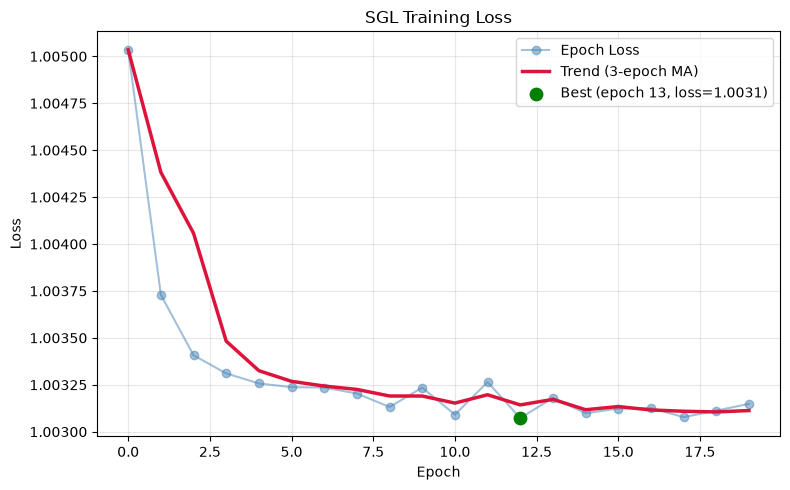

Final Loss : 1.0031
Best Loss  : 1.0031 @ epoch 13


In [39]:
def moving_average(values, window=3):
    smoothed = []
    for i in range(len(values)):
        start = max(0, i - window + 1)
        smoothed.append(sum(values[start:i+1]) / (i - start + 1))
    return smoothed

smoothed = moving_average(history, window=3)
best_epoch = int(np.argmin(history)) + 1
final_loss = history[-1]

plt.figure(figsize=(8, 5))

plt.plot(
    history,
    marker="o",
    linewidth=1.5,
    alpha=0.5,
    color="steelblue",
    label="Epoch Loss"
)

plt.plot(
    smoothed,
    linewidth=2.5,
    color="crimson",
    label="Trend (3-epoch MA)"
)

plt.scatter(
    [best_epoch - 1],
    [min(history)],
    s=80,
    color="green",
    zorder=5,
    label=f"Best (epoch {best_epoch}, loss={min(history):.4f})"
)

plt.title("SGL Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid(True, alpha=0.3)
plt.legend(loc="upper right")
plt.tight_layout()
plt.show()

print(f"Final Loss : {final_loss:.4f}")
print(f"Best Loss  : {min(history):.4f} @ epoch {best_epoch}")

In [40]:
model.eval()

embedding1, embedding2 = model(

    graph_view1,

    graph_view2

)

final_embeddings = (

    embedding1

    +

    embedding2

) / 2

In [41]:
def recommend(

    user_id,

    top_k=10

):

    user_embedding = final_embeddings[

        user_id

    ]

    item_embeddings = final_embeddings[

        NUM_USERS:

    ]

    scores = torch.matmul(

        item_embeddings,

        user_embedding

    )

    _, indices = torch.topk(

        scores,

        top_k

    )

    return indices.cpu().numpy()

In [42]:
recommend(

    user_id=0,

    top_k=10

)

array([1138,   31,  198,  318,  844,  323,  778,  176,   84,   65])

In [43]:
prediction_df = test_df.copy()

scores = []

for row in prediction_df.itertuples():

    score = torch.dot(

        final_embeddings[

            row.user_id

        ],

        final_embeddings[

            NUM_USERS +

            row.movie_id

        ]

    ).item()

    scores.append(score)

prediction_df["score"] = scores

In [44]:
prediction_df["probability"] = (

    prediction_df["score"]

    -

    prediction_df["score"].min()

) / (

    prediction_df["score"].max()

    -

    prediction_df["score"].min()

)

In [45]:
prediction_df["prediction"] = (

    prediction_df["probability"]

    >=

    0.5

).astype(int)

In [46]:
accuracy = accuracy_score(

    prediction_df["label"],

    prediction_df["prediction"]

)

auc = roc_auc_score(

    prediction_df["label"],

    prediction_df["probability"]

)

print(

    f"Accuracy : {accuracy:.4f}"

)

print(

    f"AUC : {auc:.4f}"
)

Accuracy : 0.5129
AUC : 0.5026


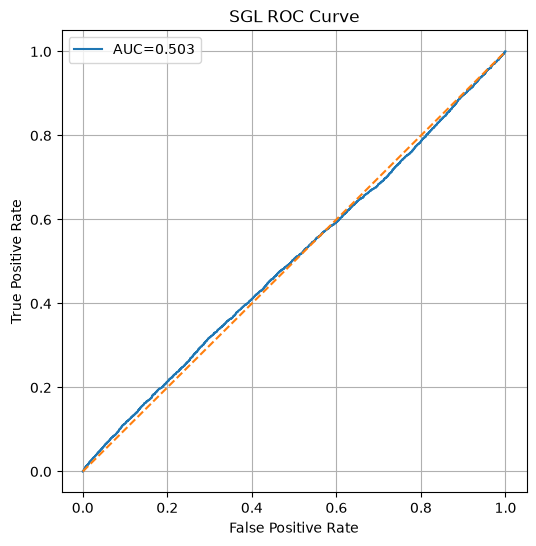

In [47]:
fpr, tpr, _ = roc_curve(

    prediction_df["label"],

    prediction_df["probability"]

)

plt.figure(

    figsize=(6,6)

)

plt.plot(

    fpr,

    tpr,

    label=f"AUC={auc:.3f}"

)

plt.plot(

    [0,1],

    [0,1],

    "--"

)

plt.xlabel(

    "False Positive Rate"

)

plt.ylabel(

    "True Positive Rate"

)

plt.title(

    "SGL ROC Curve"

)

plt.legend()

plt.grid(True)

plt.show()

In [48]:
def precision_at_k(

    prediction_df,

    k=10

):

    precisions = []

    grouped = prediction_df.groupby(

        "user_id"

    )

    for _, group in grouped:

        top_k = group.sort_values(

            "probability",

            ascending=False

        ).head(k)

        precisions.append(

            top_k["label"].mean()

        )

    return np.mean(

        precisions

    )
    
    
    
def recall_at_k(

    prediction_df,

    k=10

):

    recalls = []

    grouped = prediction_df.groupby(

        "user_id"

    )

    for _, group in grouped:

        relevant = group["label"].sum()

        if relevant == 0:

            continue

        top_k = group.sort_values(

            "probability",

            ascending=False

        ).head(k)

        hits = top_k["label"].sum()

        recalls.append(

            hits / relevant

        )

    return np.mean(

        recalls

    )
    
    
    
def hit_rate_at_k(

    prediction_df,

    k=10

):

    hits = []

    grouped = prediction_df.groupby(

        "user_id"

    )

    for _, group in grouped:

        top_k = group.sort_values(

            "probability",

            ascending=False

        ).head(k)

        hits.append(

            top_k["label"].sum() > 0

        )

    return np.mean(

        hits

    )

In [49]:
precision = precision_at_k(

    prediction_df,

    k=10

)

recall = recall_at_k(

    prediction_df,

    k=10

)

hitrate = hit_rate_at_k(

    prediction_df,

    k=10

)

In [50]:
metrics = pd.DataFrame(

    {

        "Metric":[

            "Accuracy",

            "AUC",

            "Precision@10",

            "Recall@10",

            "HitRate@10"

        ],

        "Value":[

            accuracy,

            auc,

            precision,

            recall,

            hitrate

        ]

    }

)

metrics

,Metric,Value
0,Accuracy,0.512900
1,AUC,0.502615
2,Precision@10,0.581112
3,Recall@10,0.669553
4,HitRate@10,0.973489


In [51]:
comparison = pd.DataFrame(

    {

        "Model":[

            "Ranking MLP",

            "Wide & Deep",

            "DeepFM",

            "DLRM",

            "DCN v1",

            "DCN v2",

            "LightGCN",

            "NGCF"

        ],

        "Accuracy":[

            0.8400,

            0.8334,

            0.6816,

            0.7084,

            0.6681,

            0.6820,

            0.4803,

            accuracy

        ],

        "AUC":[

            0.7862,

            0.7763,

            0.7386,

            0.7739,

            0.7317,

            0.7406,

            0.5924,

            auc

        ],

        "Precision@10":[

            0.9102,

            0.8831,

            0.6500,

            0.6632,

            0.6480,

            0.6485,

            0.6792,

            precision

        ],

        "Recall@10":[

            0.5092,

            0.6886,

            0.7169,

            0.7264,

            0.7142,

            0.7138,

            0.2221,

            recall

        ],

        "HitRate@10":[

            0.9978,

            0.9957,

            0.9767,

            0.9777,

            0.9756,

            0.9777,

            0.9979,

            hitrate

        ]

    }

)

comparison
comparison.loc[len(comparison)] = [

    "SGL",

    accuracy,

    auc,

    precision,

    recall,

    hitrate

]

comparison

,Model,Accuracy,AUC,Precision@10,Recall@10,HitRate@10
0,Ranking MLP,0.8400,0.786200,0.910200,0.509200,0.997800
1,Wide & Deep,0.8334,0.776300,0.883100,0.688600,0.995700
2,DeepFM,0.6816,0.738600,0.650000,0.716900,0.976700
3,DLRM,0.7084,0.773900,0.663200,0.726400,0.977700
4,DCN v1,0.6681,0.731700,0.648000,0.714200,0.975600
5,DCN v2,0.6820,0.740600,0.648500,0.713800,0.977700
6,LightGCN,0.4803,0.592400,0.679200,0.222100,0.997900
7,NGCF,0.5129,0.502615,0.581112,0.669553,0.973489
8,SGL,0.5129,0.502615,0.581112,0.669553,0.973489


In [52]:
for metric in [

    "Accuracy",

    "AUC",

    "Precision@10",

    "Recall@10",

    "HitRate@10"

]:

    print(f"Best {metric}")

    display(

        comparison.sort_values(

            metric,

            ascending=False

        )

    )

Best Accuracy


,Model,Accuracy,AUC,Precision@10,Recall@10,HitRate@10
0,Ranking MLP,0.8400,0.786200,0.910200,0.509200,0.997800
1,Wide & Deep,0.8334,0.776300,0.883100,0.688600,0.995700
3,DLRM,0.7084,0.773900,0.663200,0.726400,0.977700
5,DCN v2,0.6820,0.740600,0.648500,0.713800,0.977700
2,DeepFM,0.6816,0.738600,0.650000,0.716900,0.976700
4,DCN v1,0.6681,0.731700,0.648000,0.714200,0.975600
7,NGCF,0.5129,0.502615,0.581112,0.669553,0.973489
8,SGL,0.5129,0.502615,0.581112,0.669553,0.973489
6,LightGCN,0.4803,0.592400,0.679200,0.222100,0.997900


Best AUC


,Model,Accuracy,AUC,Precision@10,Recall@10,HitRate@10
0,Ranking MLP,0.8400,0.786200,0.910200,0.509200,0.997800
1,Wide & Deep,0.8334,0.776300,0.883100,0.688600,0.995700
3,DLRM,0.7084,0.773900,0.663200,0.726400,0.977700
5,DCN v2,0.6820,0.740600,0.648500,0.713800,0.977700
2,DeepFM,0.6816,0.738600,0.650000,0.716900,0.976700
4,DCN v1,0.6681,0.731700,0.648000,0.714200,0.975600
6,LightGCN,0.4803,0.592400,0.679200,0.222100,0.997900
7,NGCF,0.5129,0.502615,0.581112,0.669553,0.973489
8,SGL,0.5129,0.502615,0.581112,0.669553,0.973489


Best Precision@10


,Model,Accuracy,AUC,Precision@10,Recall@10,HitRate@10
0,Ranking MLP,0.8400,0.786200,0.910200,0.509200,0.997800
1,Wide & Deep,0.8334,0.776300,0.883100,0.688600,0.995700
6,LightGCN,0.4803,0.592400,0.679200,0.222100,0.997900
3,DLRM,0.7084,0.773900,0.663200,0.726400,0.977700
2,DeepFM,0.6816,0.738600,0.650000,0.716900,0.976700
5,DCN v2,0.6820,0.740600,0.648500,0.713800,0.977700
4,DCN v1,0.6681,0.731700,0.648000,0.714200,0.975600
7,NGCF,0.5129,0.502615,0.581112,0.669553,0.973489
8,SGL,0.5129,0.502615,0.581112,0.669553,0.973489


Best Recall@10


,Model,Accuracy,AUC,Precision@10,Recall@10,HitRate@10
3,DLRM,0.7084,0.773900,0.663200,0.726400,0.977700
2,DeepFM,0.6816,0.738600,0.650000,0.716900,0.976700
4,DCN v1,0.6681,0.731700,0.648000,0.714200,0.975600
5,DCN v2,0.6820,0.740600,0.648500,0.713800,0.977700
1,Wide & Deep,0.8334,0.776300,0.883100,0.688600,0.995700
8,SGL,0.5129,0.502615,0.581112,0.669553,0.973489
7,NGCF,0.5129,0.502615,0.581112,0.669553,0.973489
0,Ranking MLP,0.8400,0.786200,0.910200,0.509200,0.997800
6,LightGCN,0.4803,0.592400,0.679200,0.222100,0.997900


Best HitRate@10


,Model,Accuracy,AUC,Precision@10,Recall@10,HitRate@10
6,LightGCN,0.4803,0.592400,0.679200,0.222100,0.997900
0,Ranking MLP,0.8400,0.786200,0.910200,0.509200,0.997800
1,Wide & Deep,0.8334,0.776300,0.883100,0.688600,0.995700
5,DCN v2,0.6820,0.740600,0.648500,0.713800,0.977700
3,DLRM,0.7084,0.773900,0.663200,0.726400,0.977700
2,DeepFM,0.6816,0.738600,0.650000,0.716900,0.976700
4,DCN v1,0.6681,0.731700,0.648000,0.714200,0.975600
7,NGCF,0.5129,0.502615,0.581112,0.669553,0.973489
8,SGL,0.5129,0.502615,0.581112,0.669553,0.973489


# Conclusion

In this notebook, we implemented **Self-supervised Graph Learning (SGL)**, a graph recommendation model that augments LightGCN with contrastive self-supervised learning.

Key observations:

- SGL reuses the LightGCN encoder without modifying its propagation mechanism.
- Two augmented graph views are generated through edge dropout.
- InfoNCE contrastive loss encourages consistent representations across graph augmentations.
- The final objective combines Bayesian Personalized Ranking (BPR) loss with self-supervised contrastive learning.
- Contrastive learning improves embedding robustness and helps alleviate the sparsity problem commonly encountered in recommendation datasets.

SGL demonstrates that incorporating self-supervised learning into graph recommendation can significantly improve representation quality without requiring additional labels or user feedback.